# VLA C-band diagonal survey (v3)

This notebook is the executable band-survey account. It starts from the compact checksummed `vla_c_band_beam_validation_v3` bundle. It does not read a Measurement Set, invoke CASA, follow Bacchus paths, or overwrite the preserved v2 SPW-4 publication.

Full Jones is diagnostic and is not a gate. Residual Jones is not applied. This is not a production beam freeze.

## What can be used for 3C391 now

Use the opt-in selector `evla_c_diagonal_survey_v1` with the catalog root and digest recorded in the bundle. Exact native frequency only. No nearest-plane substitution and no Airy fallback. A defensible Stokes-I trial uses the sampled accepted centres around 4436–5820 MHz, not a continuous channel range. Pass A is complete; Pass B is limited to lower-C SPWs 4–6. Numerical qualification is incomplete. Upper-C is archive-integrity unverified. Imaging uses the fixed 4536/4598/4662 MHz nodes until more native planes exist.

## What changed since SPW 4

The v2 refresh reused a channel-32 residual-Jones plane. This survey does not. SPW 5 is a declared diagonal frequency-transfer test, not a full-Jones reopen. The large SPW-4 channel-24 LL and channel-40 RR excursions survive without residual Jones.

In [1]:
from pathlib import Path
import json
from IPython.display import Image, display

root = Path("src/sl1mjax/data/vla_c_band_beam_validation_v3")
manifest = json.loads((root / "manifest.json").read_text())
if manifest["publication_version"] != "vla_c_band_beam_validation_v3":
    raise RuntimeError(f"unexpected publication {manifest['publication_version']}")
if "vla_c_band_beam_validation_v2" in str(root):
    raise RuntimeError("refusing to load the frozen v2 bundle")
suitability = json.loads((root / "suitability_table.json").read_text())
handoff = json.loads((root / "imaging_handoff.json").read_text())
ledger = json.loads((root / "supersession_ledger.json").read_text())
phase5 = json.loads((root / "phase5_diagnostics.json").read_text())
slot_status = json.loads((root / "slot_status.json").read_text())
print(root.resolve())
print("publication", manifest["publication_version"])
print("bundle_sha256", manifest["bundle_sha256"])
print("catalog_digest", manifest.get("catalog_digest"))
print("production_accepted", manifest["production_accepted"])
print("full_jones_is_gate", manifest["full_jones_is_gate"])
print("residual_jones", manifest["residual_jones_policy"])
print("interpolation", manifest["interpolation_policy"])
print("n_scored", suitability["n_scored"])
print("slot_status", slot_status["n_scored"], "of", slot_status["n_slots"], slot_status["counts"])
print("pass_a_survey_complete", slot_status.get("pass_a_survey_complete"))


/Users/stephen/checkouts/SL1MJax/src/sl1mjax/data/vla_c_band_beam_validation_v3
publication vla_c_band_beam_validation_v3
bundle_sha256 8cd815eb08e99a986ee0413e80d681641ebbceea87cd35f0d4859b48f3ed5e61
catalog_digest 828c9ece95d3bc6c95bed8091840a6bceea3214e59b42895530b23224973d843
production_accepted False
full_jones_is_gate False
residual_jones not_applied
interpolation refused
n_scored 44
slot_status 44 of 160 {'complete': 28, 'pass_a_only': 116, 'scientifically-qualified': 16}
pass_a_survey_complete True


In [2]:
print("usable main-lobe slots")
print("exec     SPW  ch   MHz     RR      LL")
for slot in handoff["usable_main_lobe_slots"]:
    mhz = slot["frequency_hz"] / 1.0e6
    print(
        f"{slot.get('execution') or '':<8} {slot['spectral_window_id']:>3} "
        f"{slot['channel']:>3} {mhz:7.0f} {slot['main_lobe_rr']:.5f} "
        f"{slot['main_lobe_ll']:.5f}"
    )
print()
print("limitation slots")
for slot in handoff["limitation_slots"]:
    mhz = slot["frequency_hz"] / 1.0e6
    print(
        f"{slot.get('execution') or '':<8} {slot['spectral_window_id']:>3} "
        f"{slot['channel']:>3} {mhz:7.0f} {slot['main_lobe_rr']:.5f} "
        f"{slot['main_lobe_ll']:.5f} {slot.get('status')}"
    )


usable main-lobe slots
exec     SPW  ch   MHz     RR      LL
lower_c    3  32    4436 0.00535 0.00567
lower_c    4   8    4516 0.00959 0.00961
lower_c    4  32    4564 0.00598 0.00538
lower_c    5  24    4676 0.00596 0.00651
lower_c    5  32    4692 0.00589 0.00596
lower_c    5  40    4708 0.00646 0.00615
lower_c    6  24    4804 0.00625 0.00607
lower_c    6  32    4820 0.00554 0.00584
lower_c    6  40    4836 0.00611 0.00614
lower_c    7  32    4948 0.00649 0.00583
lower_c    8  32    5052 0.00596 0.00646
lower_c    9  32    5180 0.00620 0.00636
lower_c   11  32    5436 0.00678 0.00683
lower_c   12  32    5564 0.00684 0.00684
lower_c   13  32    5692 0.00649 0.00645
lower_c   14  32    5820 0.00699 0.00686

limitation slots
lower_c    0  32    4052 0.06961 0.10250 complete
lower_c    1  32    4180 0.25148 0.23441 complete
lower_c    2  32    4308 0.94662 0.94029 complete
lower_c    4  24    4548 0.00585 0.01397 complete
lower_c    4  40    4580 0.01641 0.00618 complete
lower_c    4  5

In [3]:
print("supersession")
for entry in ledger["entries"]:
    print(f"- {entry['item']}: {entry['status']} ({entry['reason']})")
print()
print("smoke command")
print(handoff.get("smoke_command") or handoff["command"])
print()
print("mosaic command")
print(handoff.get("mosaic_command") or handoff["command"])


supersession
- generic commanded HOLORASTER comparison: historical (Used generic VLA feed at commanded AZELGEO offsets)
- vla_c_band_beam_validation_v2 SPW-4 refresh: preserved_checkpoint (Channel-32 residual Jones reused across its series; not band-ready)
- SPW 5: declared_diagonal_frequency_transfer (Opened under identity residual Jones; not a full-Jones reopen)
- channel-32 residual Jones apply: not_applied (Survey policy is identity residual Jones)
- width 1.04 / inherited squint / convention ladder: not_inherited (Unit EVLA-C physical model only)
- full Jones scientific acceptance: diagnostic_not_gate (Refresh outcome inconclusive_sensitivity; not required for imaging)
- 3C391 seven-pointing survey smoke: complete (Finite train/reload loss on C1–C7 at 4536/4598/4662 MHz)
- Pass B within-SPW extras outside SPWs 4–6: pass_a_only (Pass A complete; Pass B limited to lower-C SPWs 4–6)
- band-wide numerical convergence: incomplete (No low/mid/high aperture-resolution and angular-samplin

In [4]:
print("phase5 slots", phase5["n_slots"], "interpolation_validated", phase5["interpolation_validated"])
print("freq_MHz  SPW  coarseRR  modelRR  measuredRR")
for slot in phase5["slots"]:
    coarse = (slot.get("coarse_radial_minima") or slot.get("nulls") or {}).get("RR") or {}
    model = ((slot.get("model_first_minima") or {}).get("RR") or {})
    measured = (slot.get("measured_first_null") or {}).get("RR") or {}
    coarse_txt = (
        f"{coarse['r_lo_arcmin']:.0f}-{coarse['r_hi_arcmin']:.0f}"
        if coarse.get("status") == "coarse_minimum"
        else coarse.get("status")
    )
    model_r = model.get("median_r_arcmin")
    model_txt = f"{float(model_r):.2f}" if model_r is not None and float(model_r) == float(model_r) else "nan"
    print(
        f"{slot['frequency_hz']/1e6:8.0f} {slot.get('spectral_window_id')}  "
        f"{coarse_txt}  {model_txt}  {measured.get('status')}"
    )


phase5 slots 44 interpolation_validated False
freq_MHz  SPW  coarseRR  modelRR  measuredRR
    4052 0  unresolved  10.18  bracketed_unresolved_zero
    4180 1  unresolved  10.18  bracketed_unresolved_zero
    4308 2  20-30  10.18  bracketed_unresolved_zero
    4436 3  20-30  10.18  bracketed_unresolved_zero
    4516 4  20-30  10.18  bracketed_unresolved_zero
    4548 4  20-30  9.16  bracketed_unresolved_zero
    4564 4  20-30  9.16  bracketed_unresolved_zero
    4580 4  20-30  9.16  bracketed_unresolved_zero
    4612 4  20-30  9.16  bracketed_unresolved_zero
    4644 5  20-30  9.16  bracketed_unresolved_zero
    4676 5  20-30  9.16  bracketed_unresolved_zero
    4692 5  20-30  9.16  bracketed_unresolved_zero
    4708 5  20-30  9.16  bracketed_unresolved_zero
    4740 5  20-30  9.16  bracketed_unresolved_zero
    4772 6  unresolved  9.16  bracketed_unresolved_zero
    4804 6  unresolved  9.16  bracketed_unresolved_zero
    4820 6  unresolved  9.16  bracketed_unresolved_zero
    4836 6  

frequency_radius_suitability.png 43502


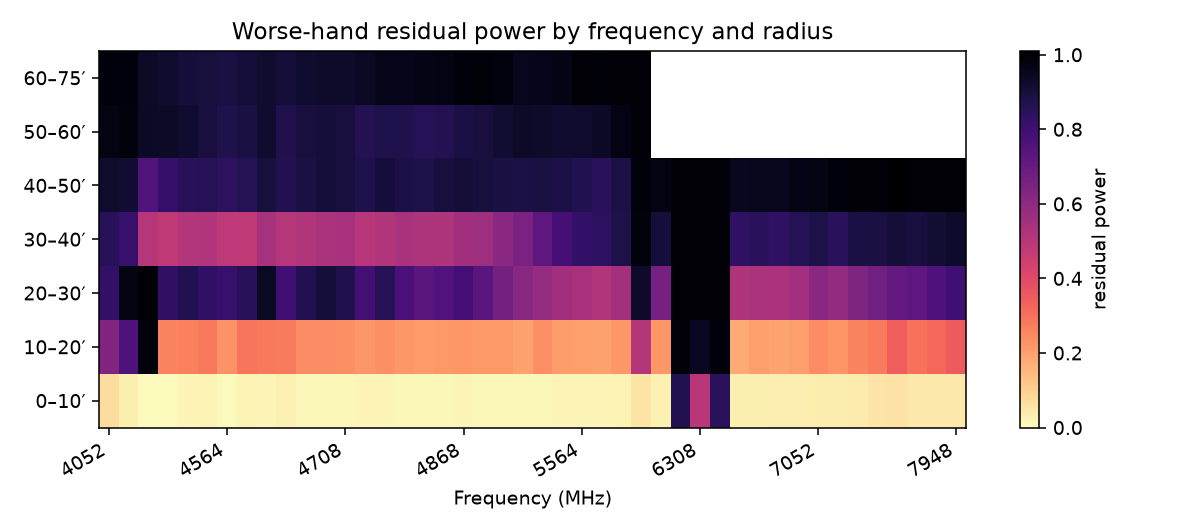

pass_b_mainlobe.png 108447


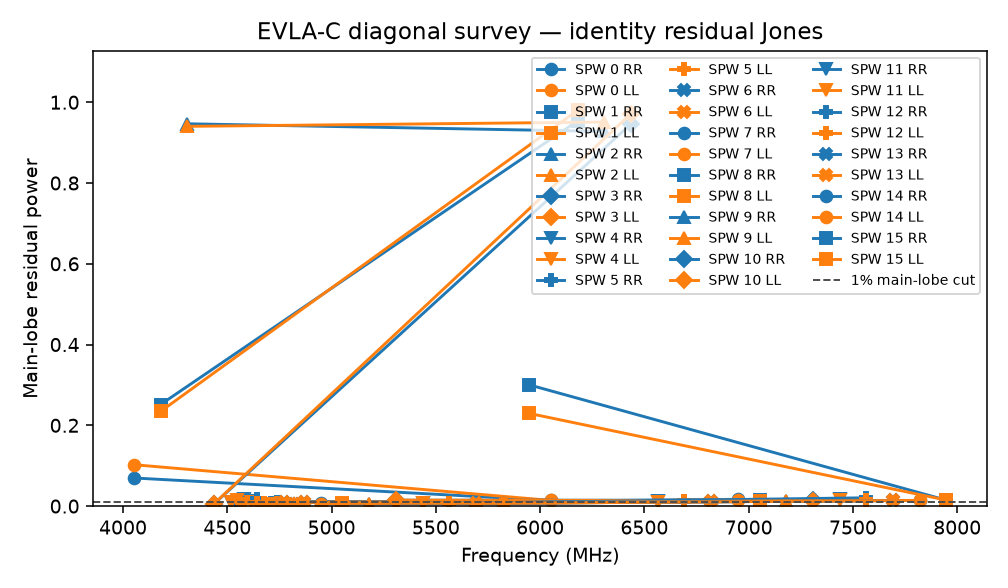

nulls_vs_frequency.png 46939


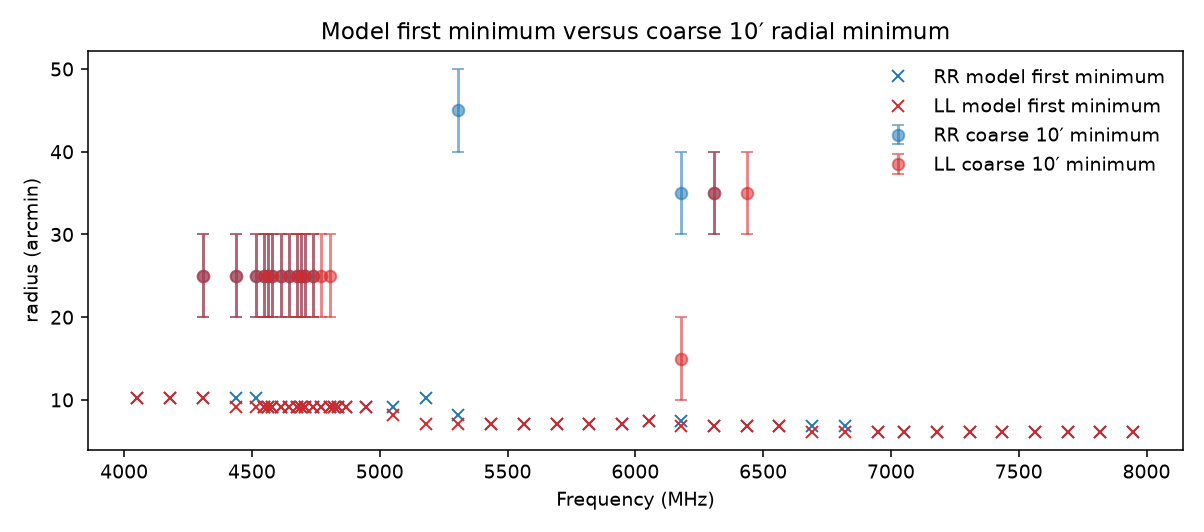

spw02_channel32_spatial.png 132360


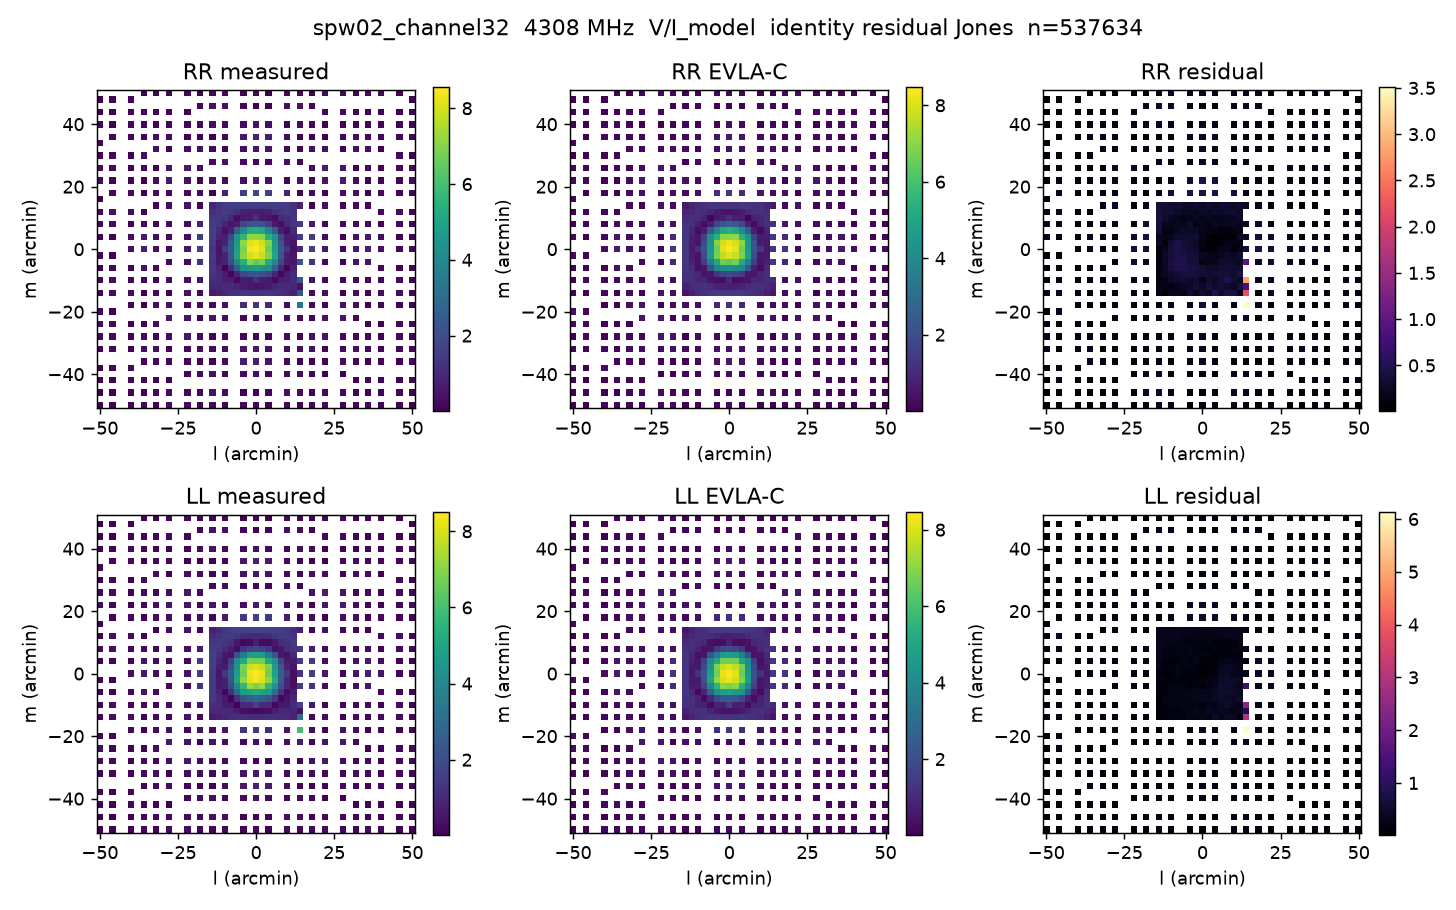

spw02_channel32_signed_cuts.png 137785


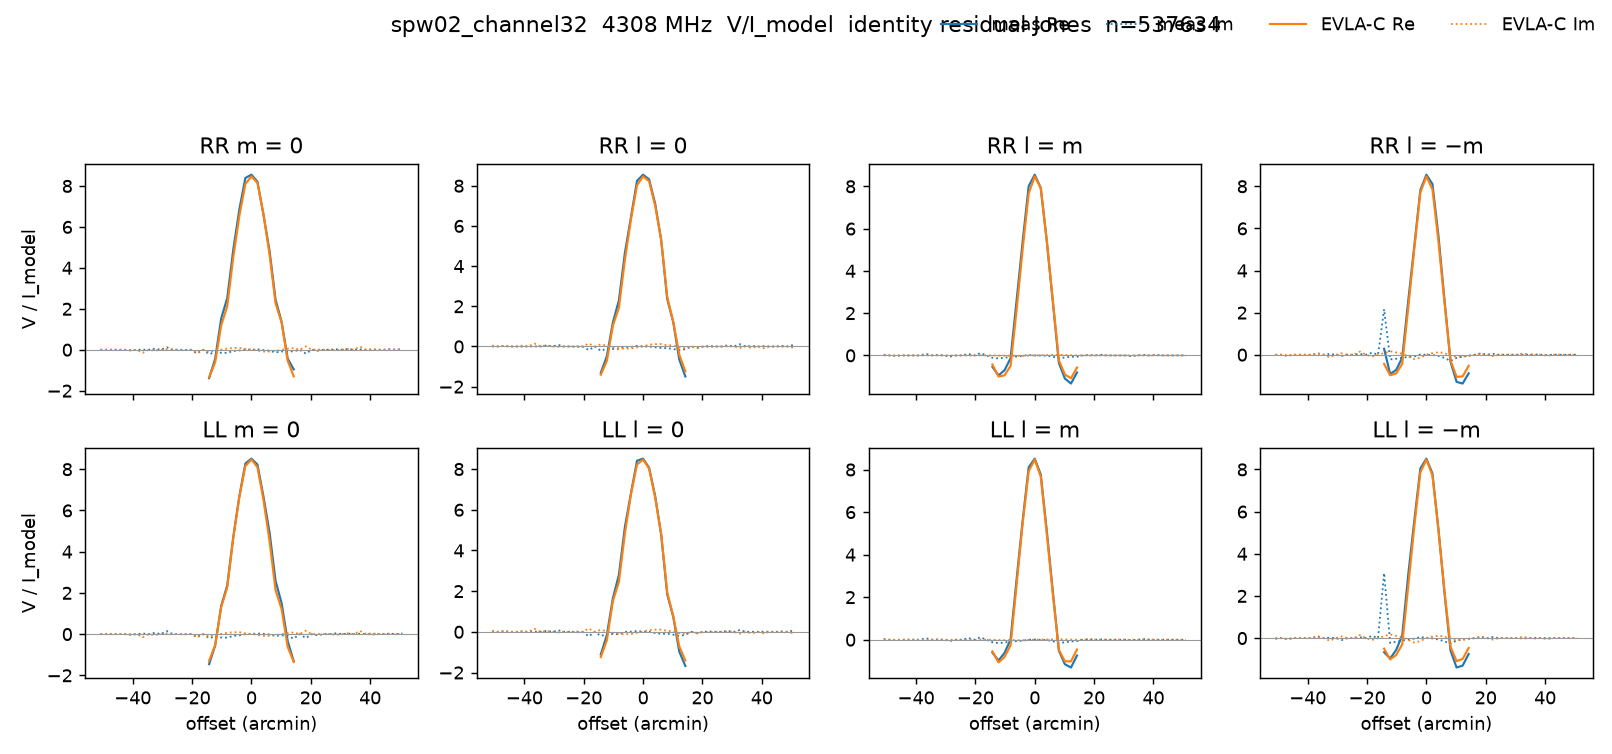

spw03_channel32_spatial.png 135677


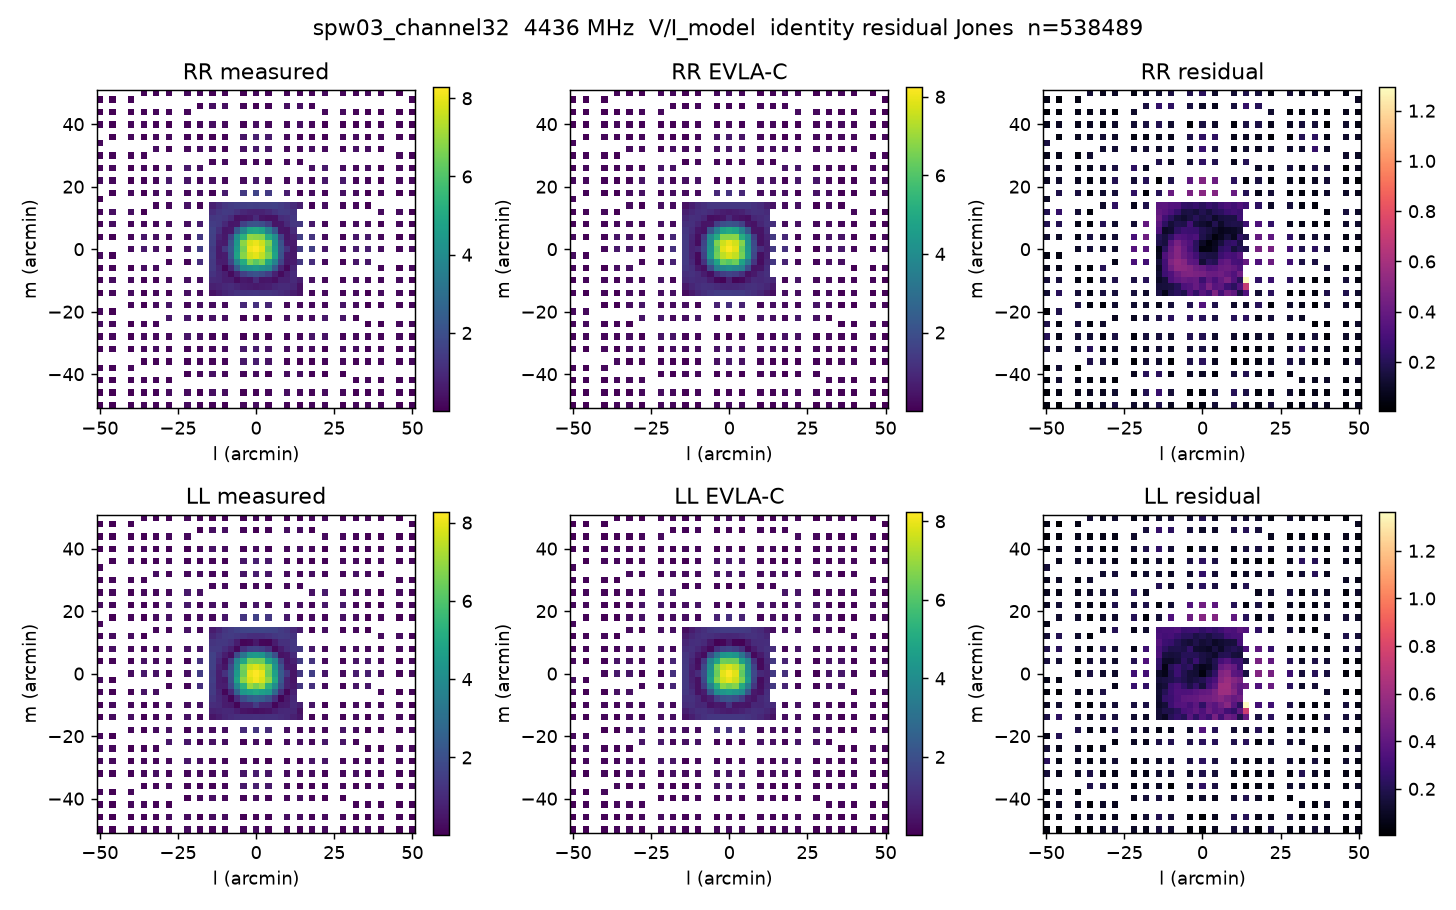

spw03_channel32_signed_cuts.png 135622


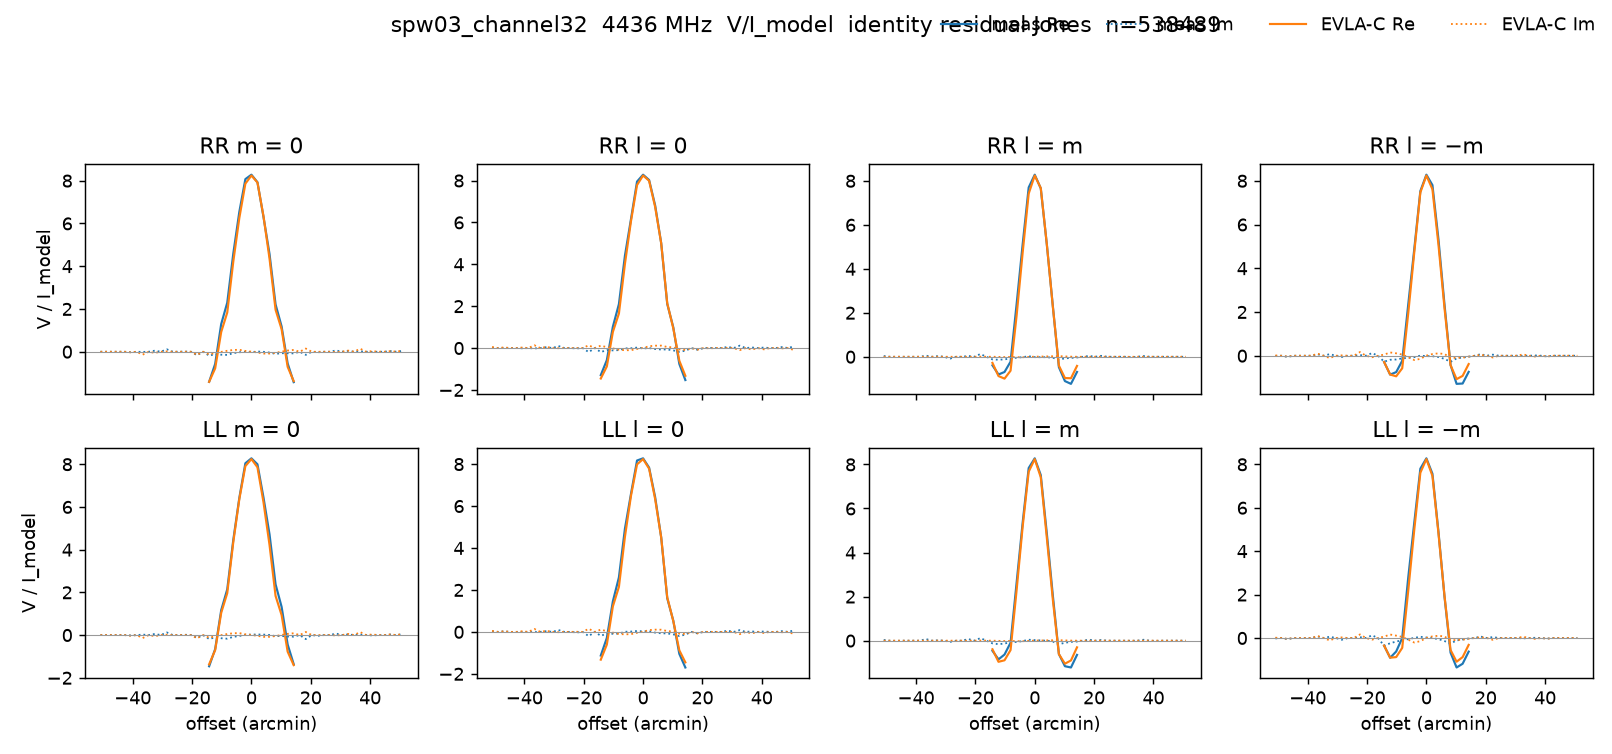

spw04_channel32_spatial.png 134910


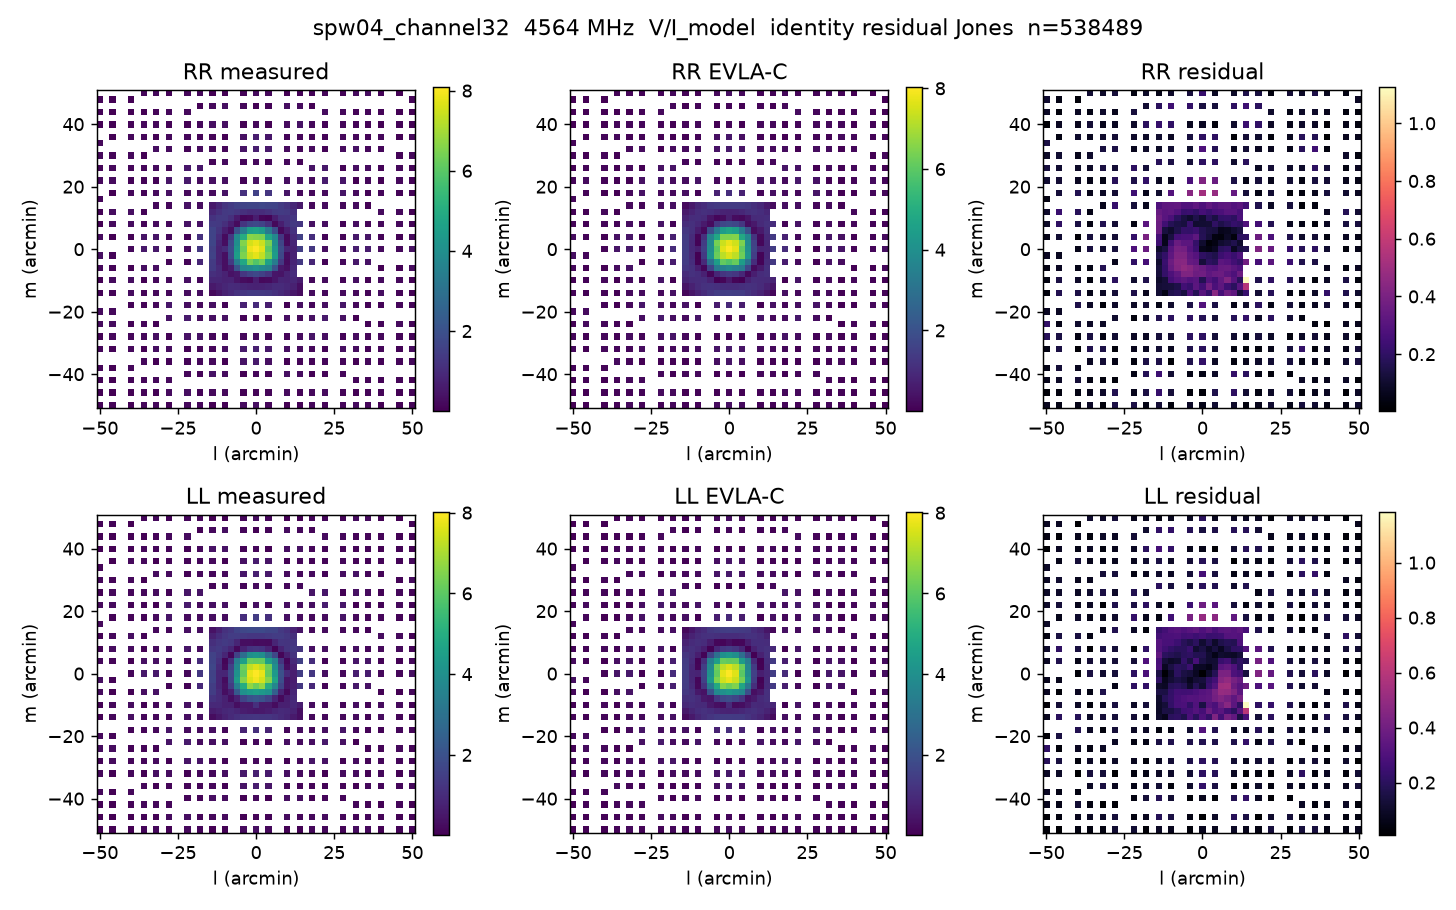

spw04_channel32_signed_cuts.png 135810


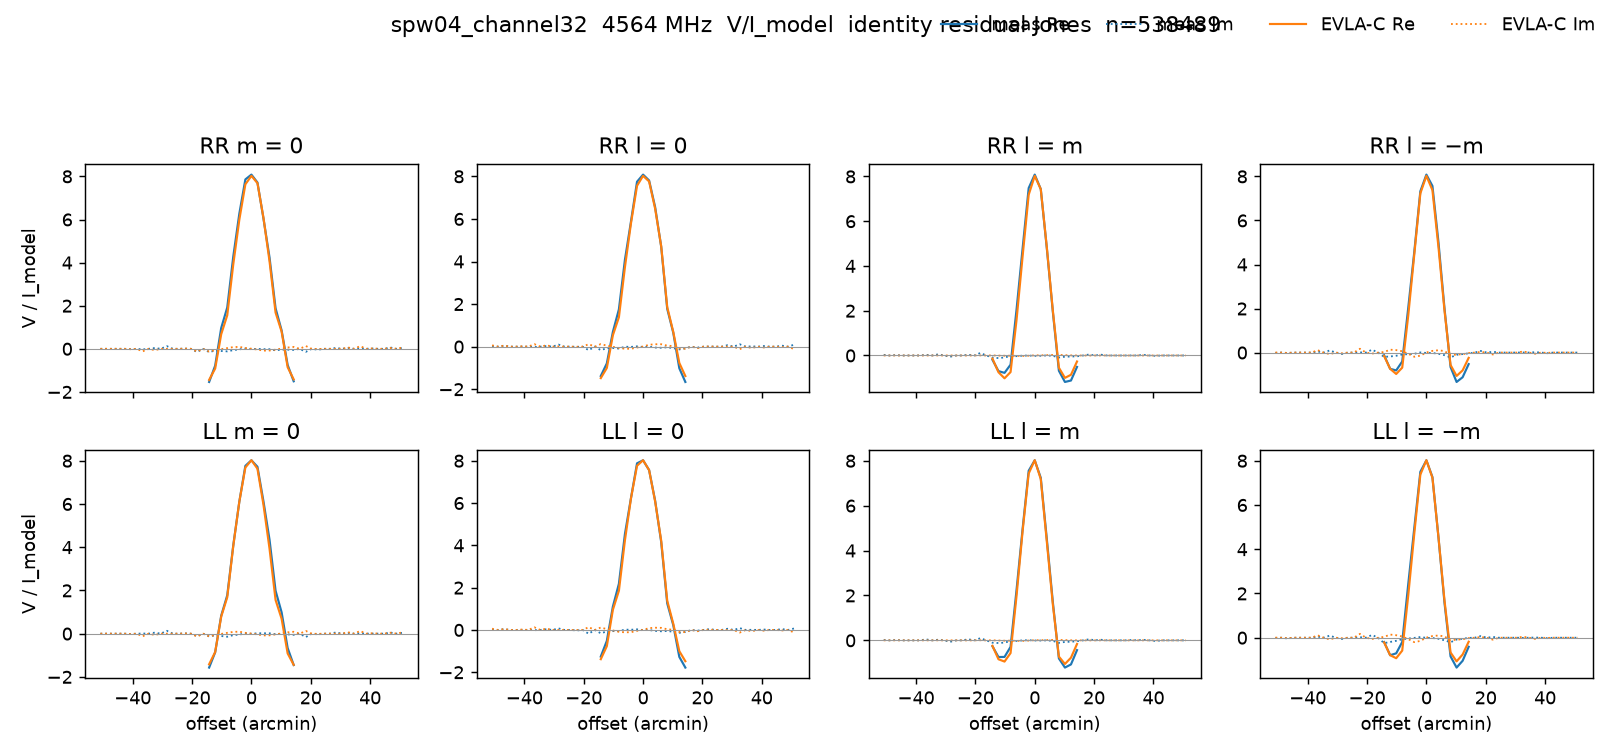

spw05_channel32_spatial.png 138141


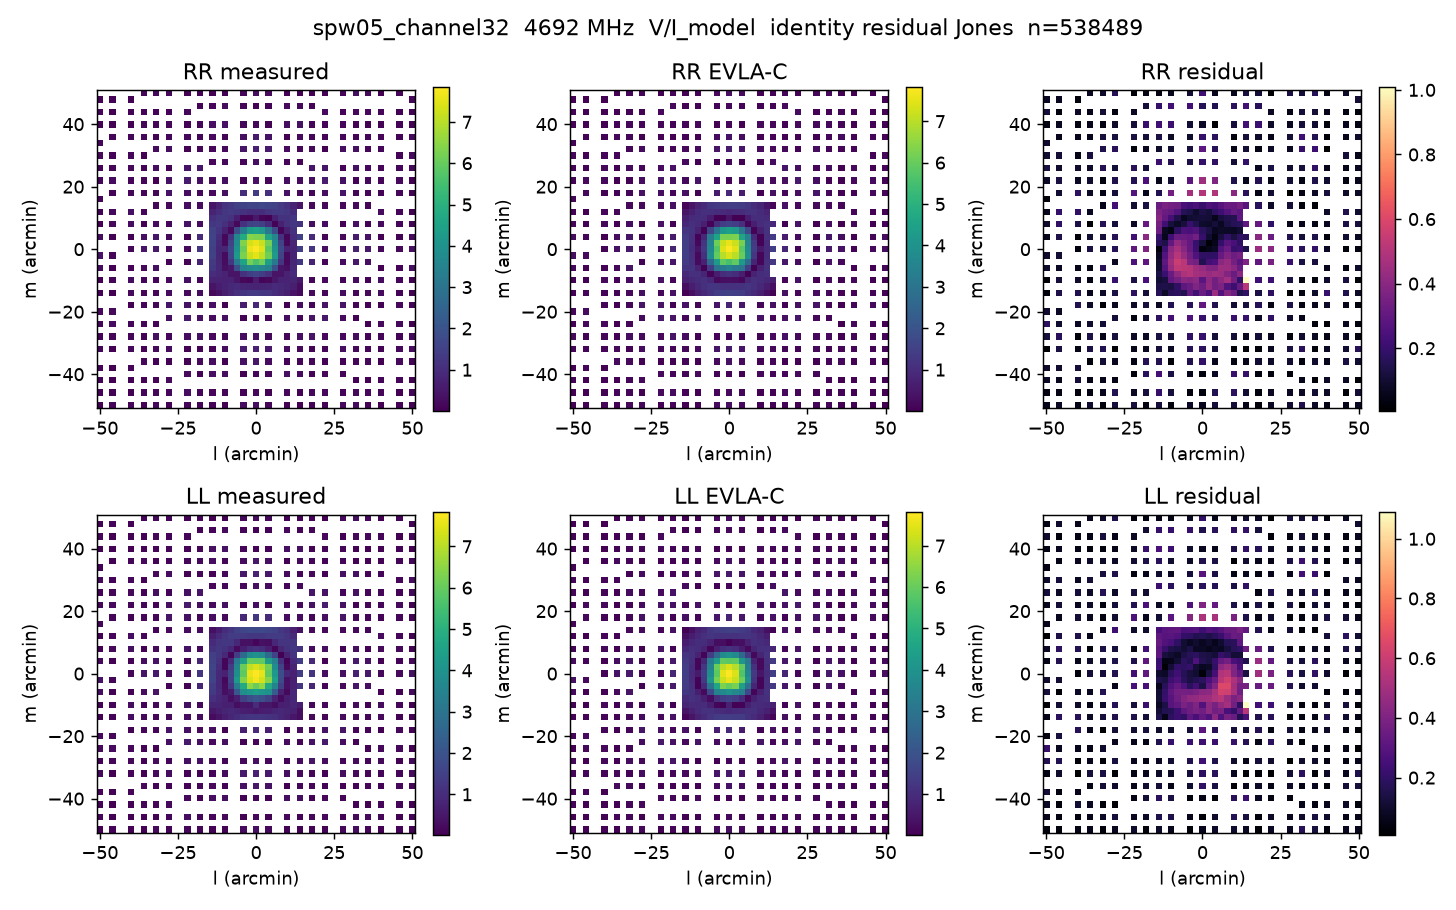

spw05_channel32_signed_cuts.png 136173


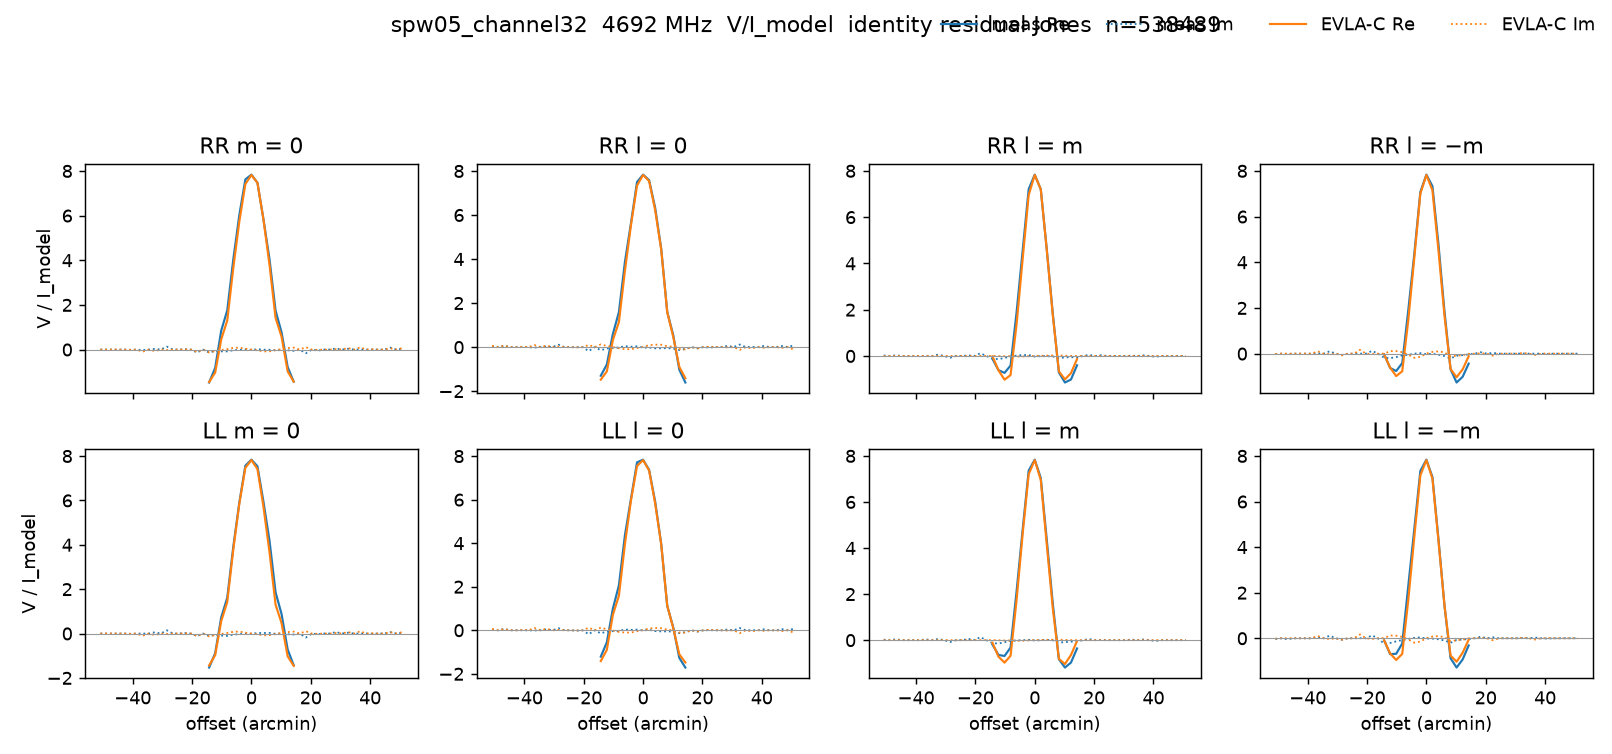

spw06_channel32_spatial.png 136803


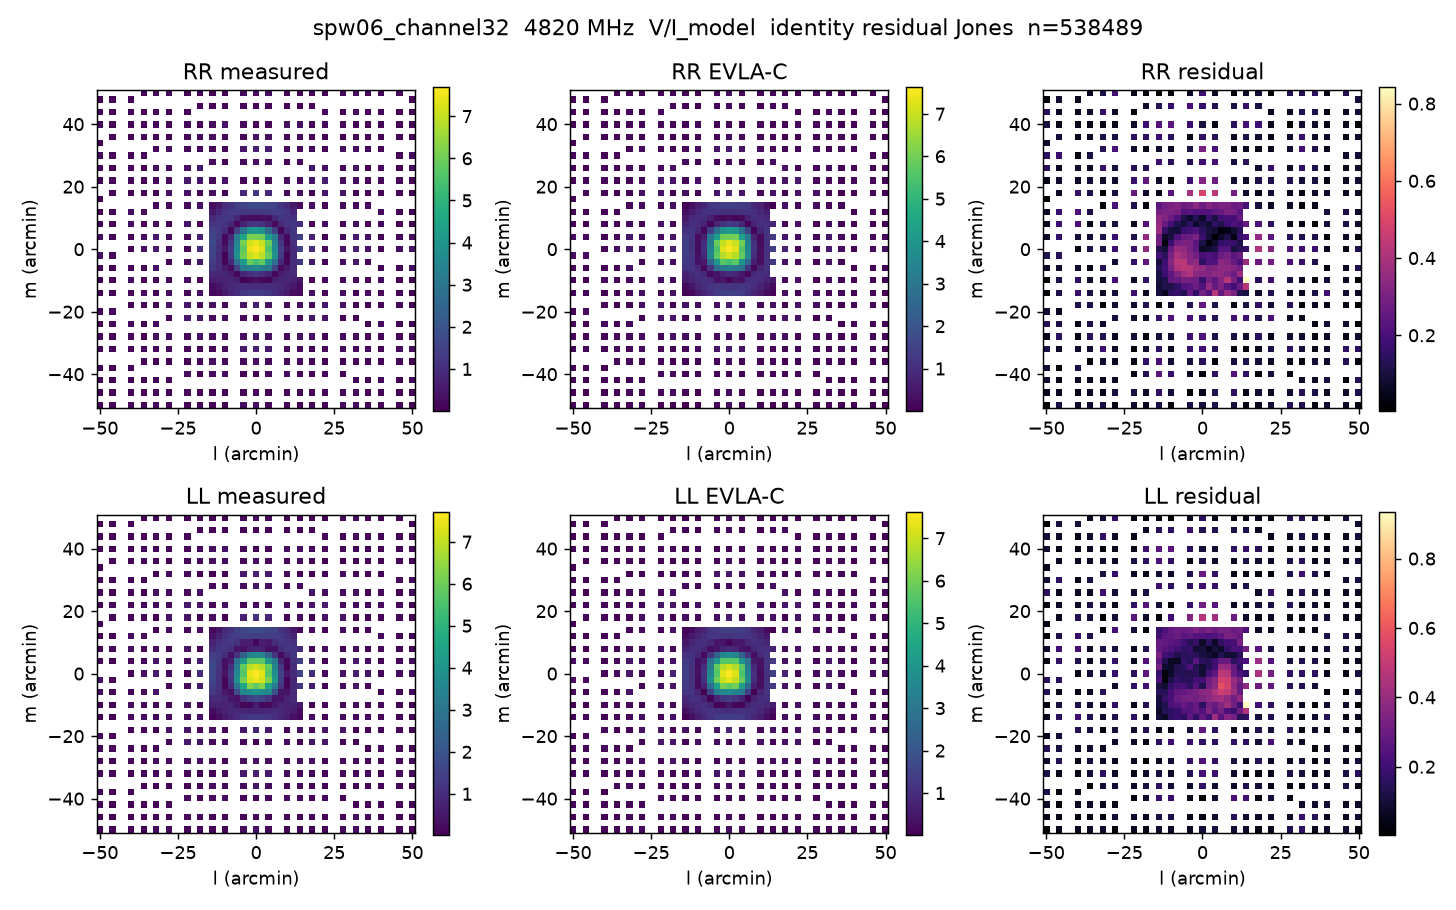

spw06_channel32_signed_cuts.png 135492


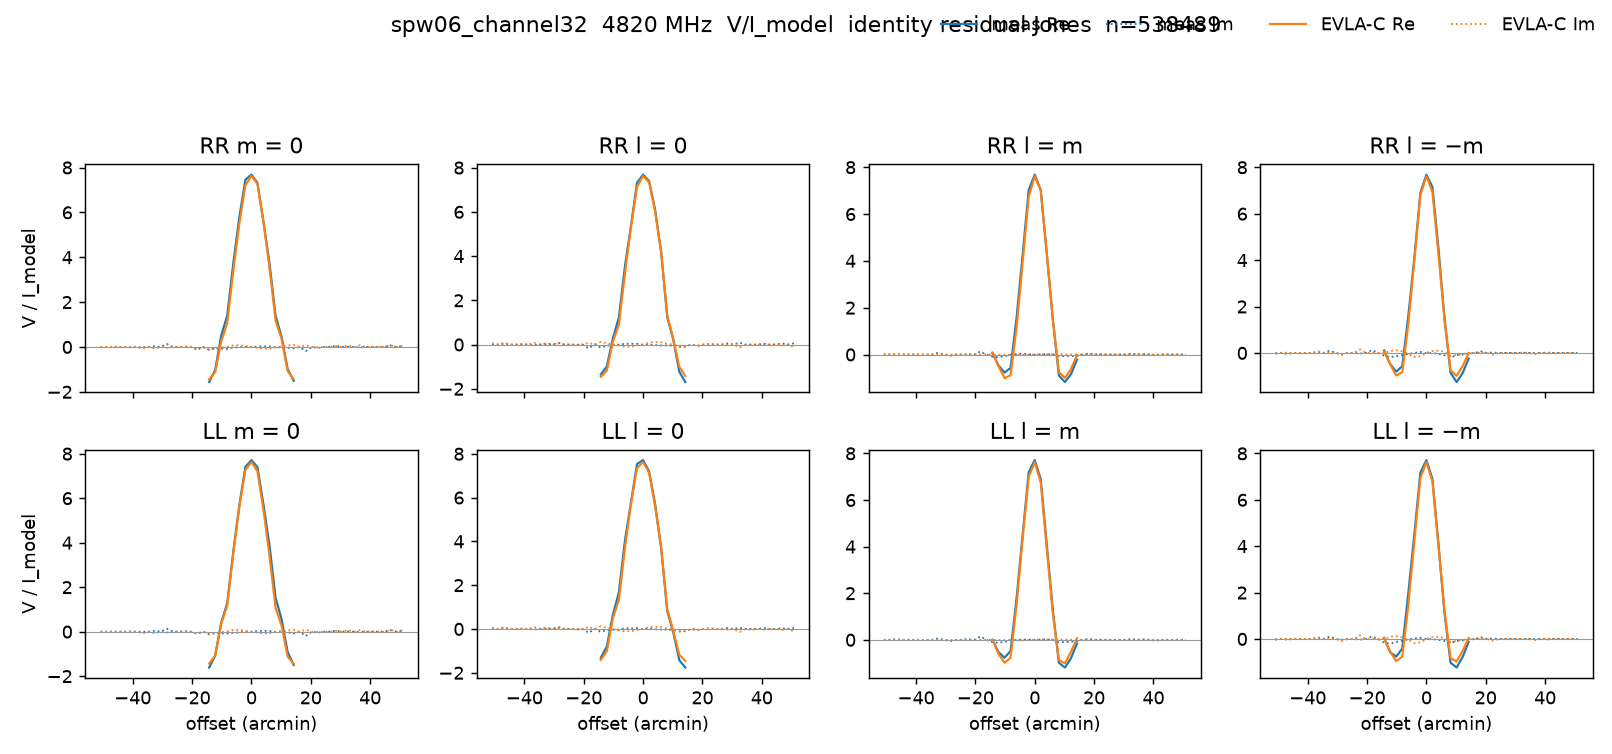

spw07_channel32_spatial.png 140056


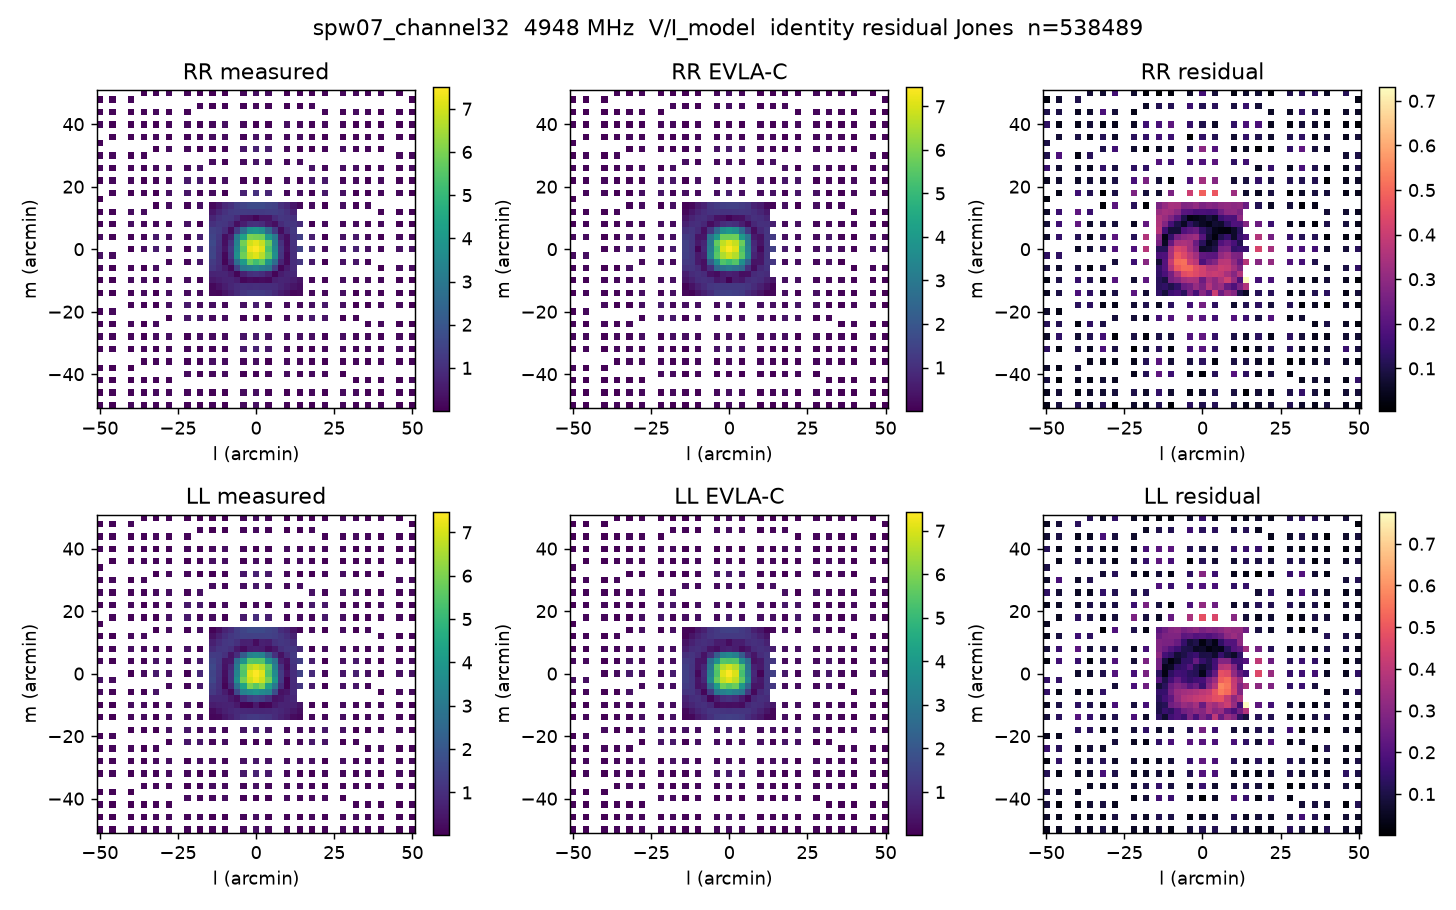

spw07_channel32_signed_cuts.png 132343


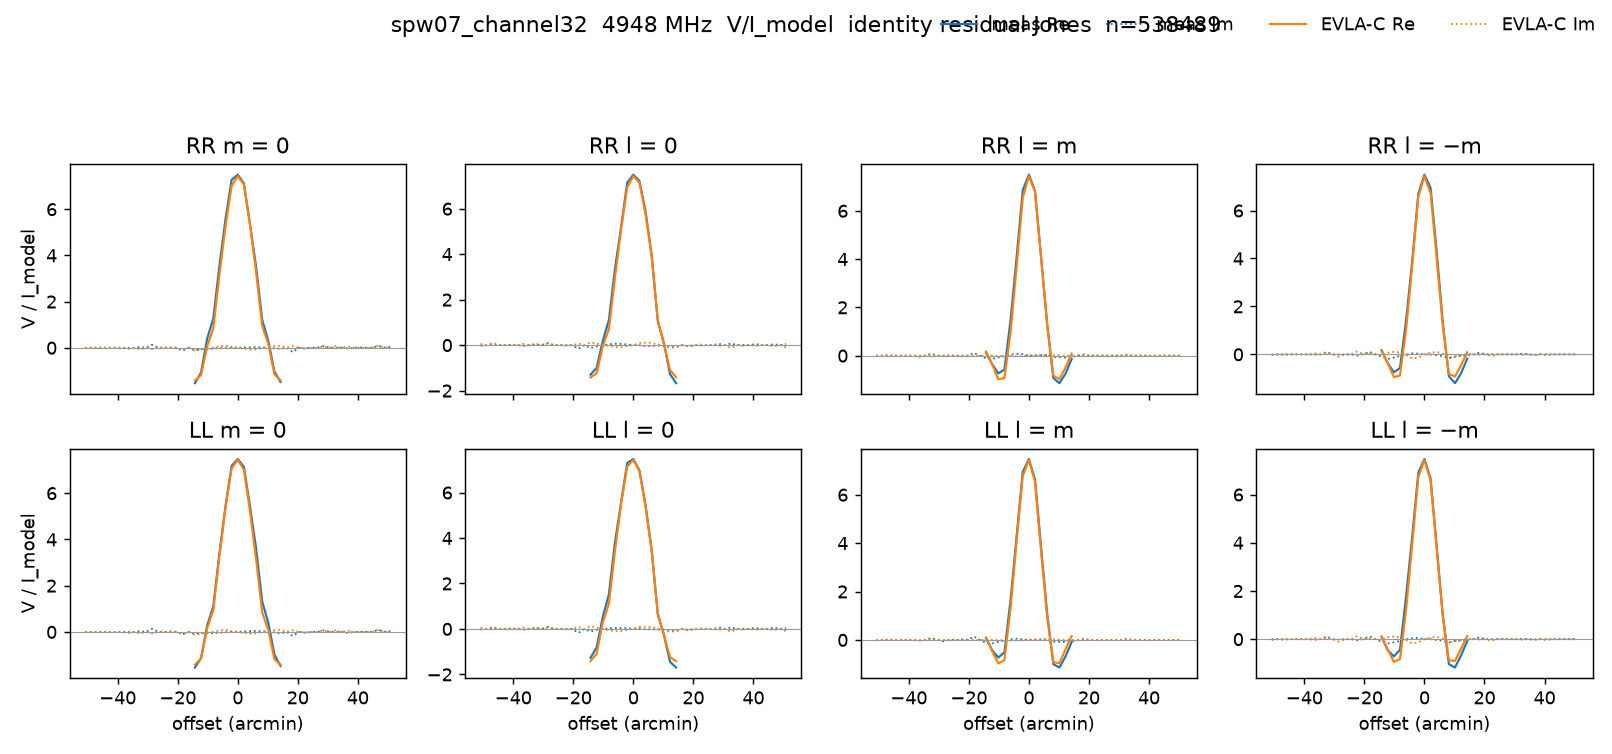

spw15_channel32_spatial.png 135157


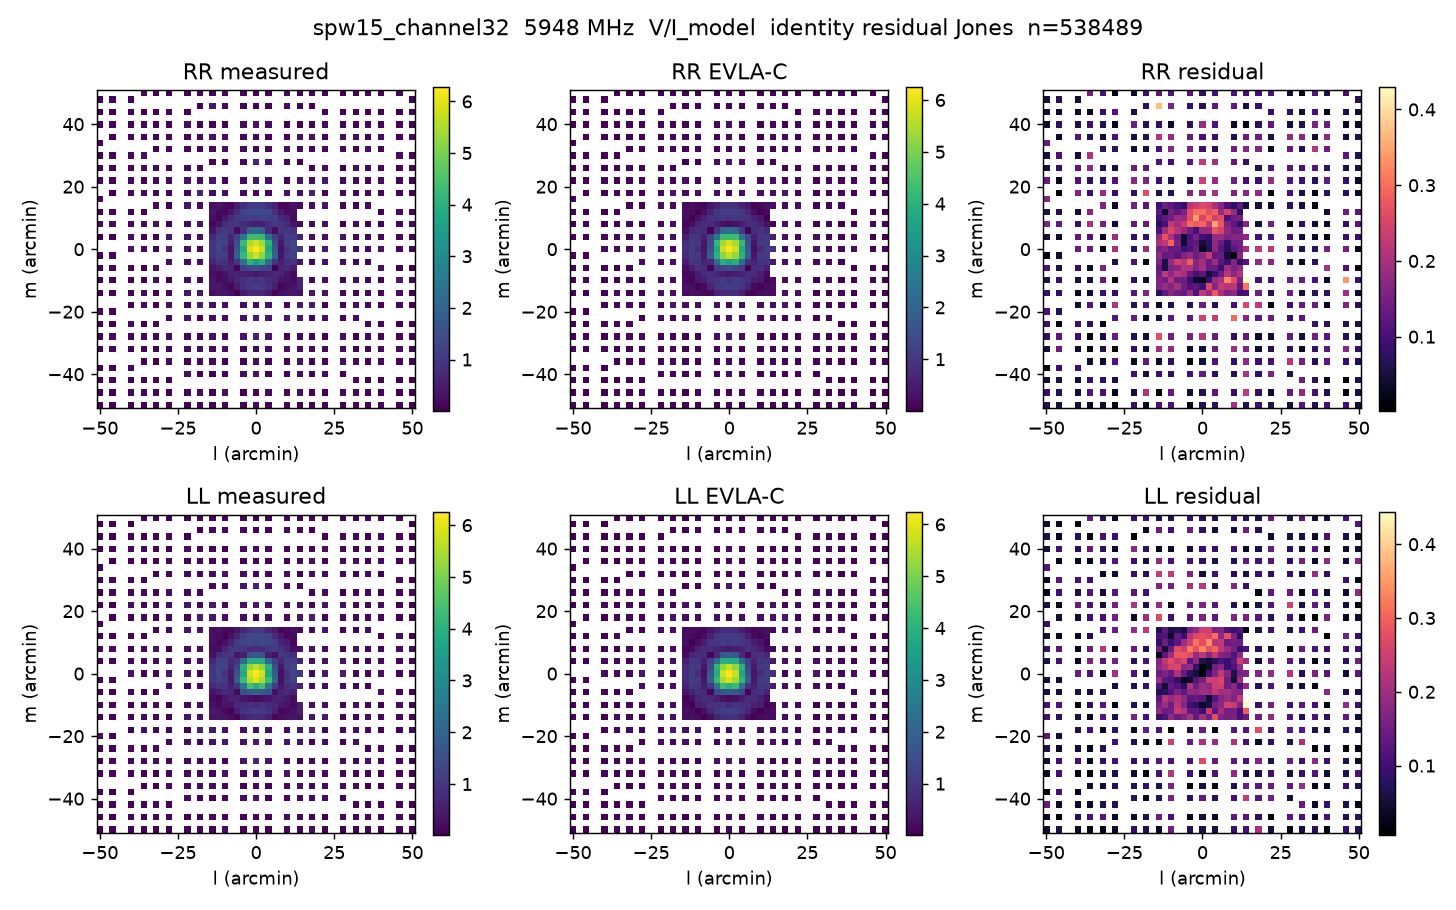

upper_c_spw00_channel32_spatial.png 140485


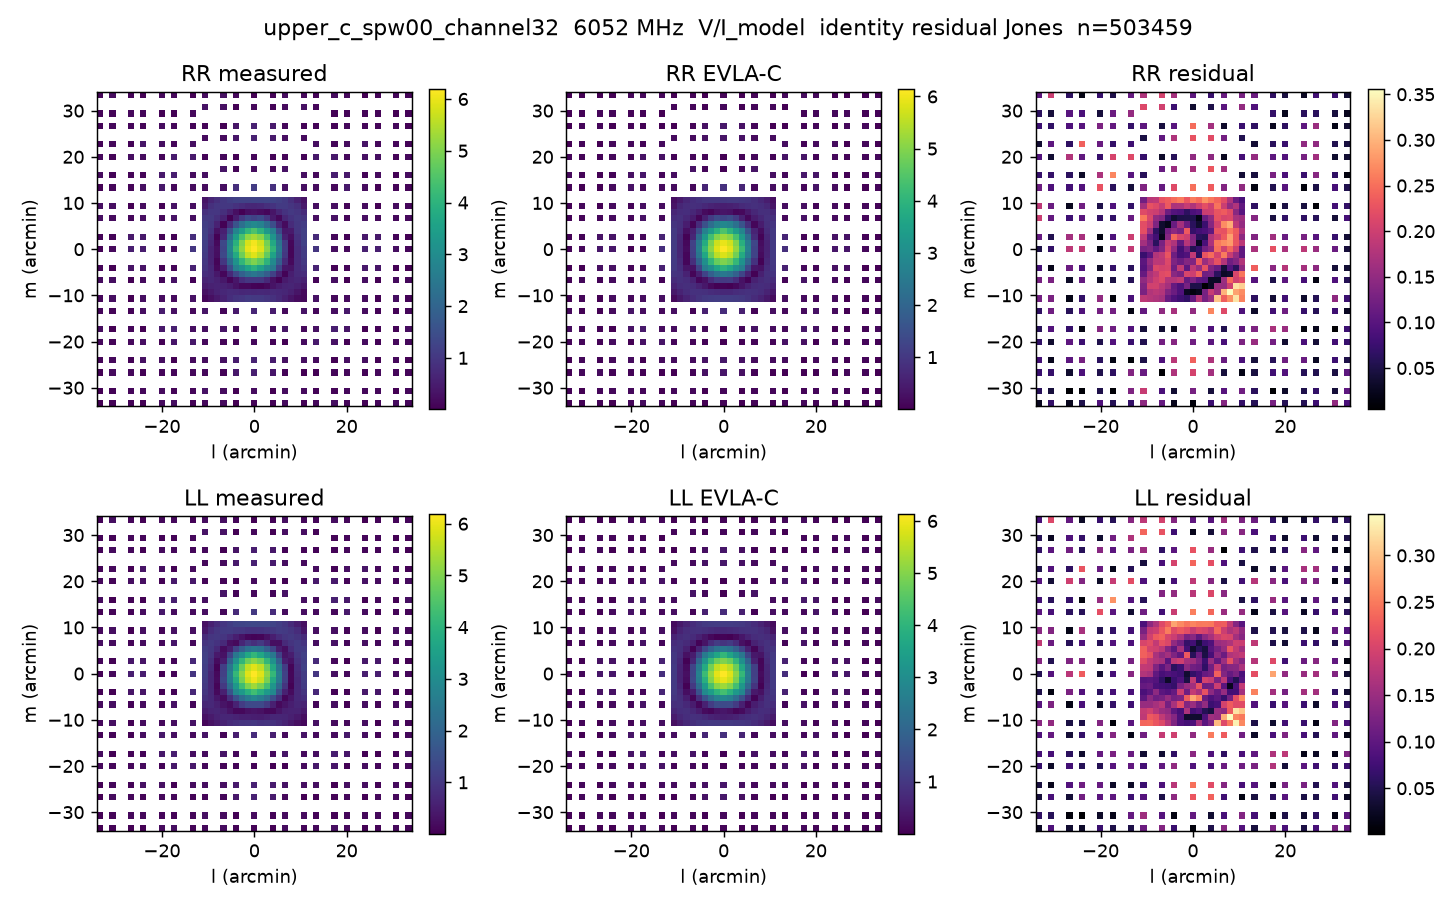

upper_c_spw01_channel32_spatial.png 135930


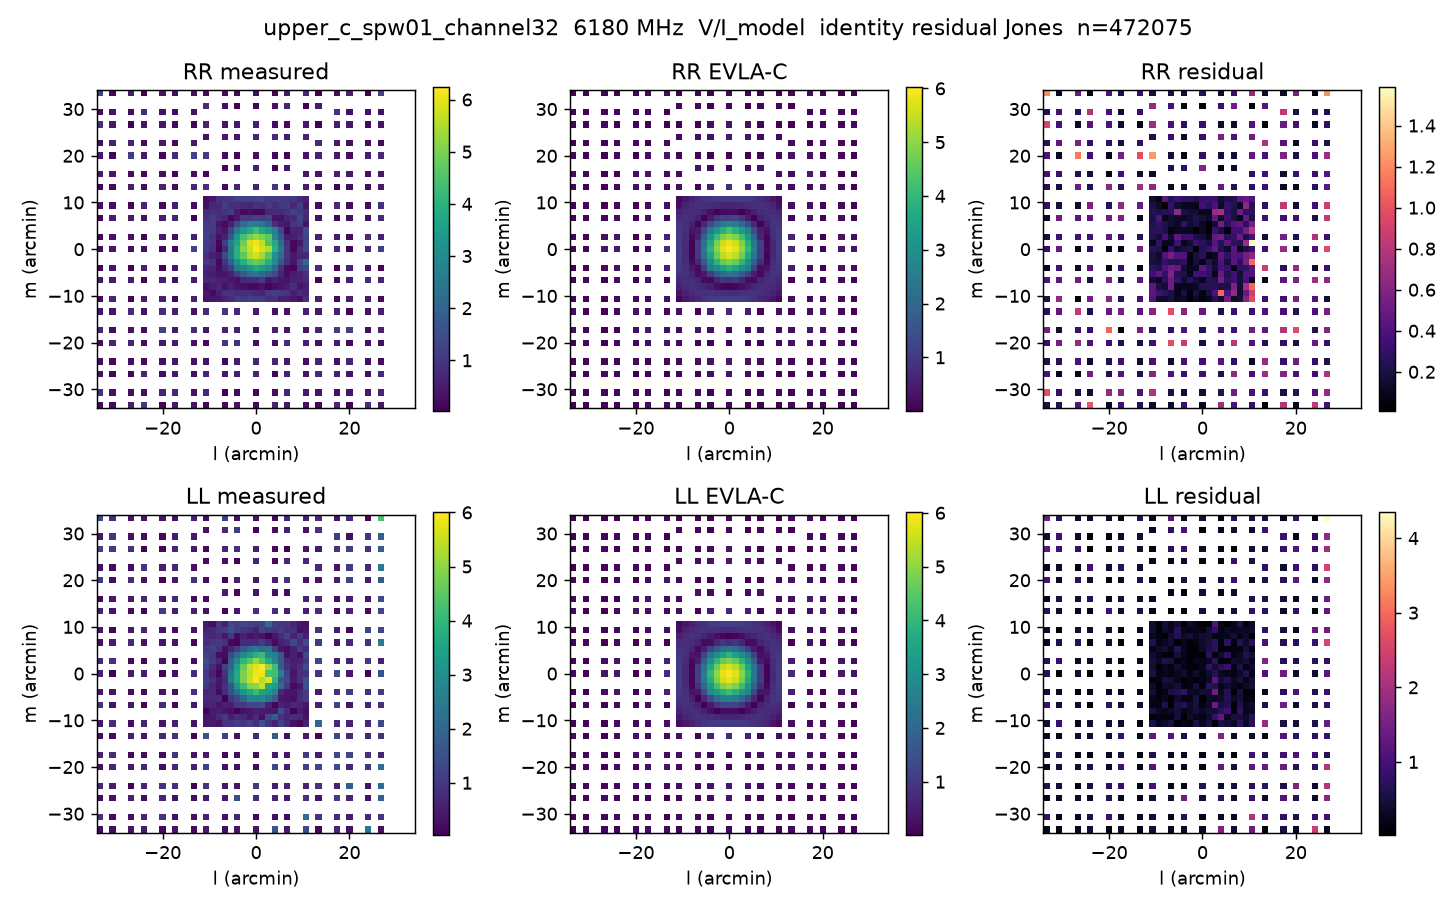

upper_c_spw15_channel32_spatial.png 137779


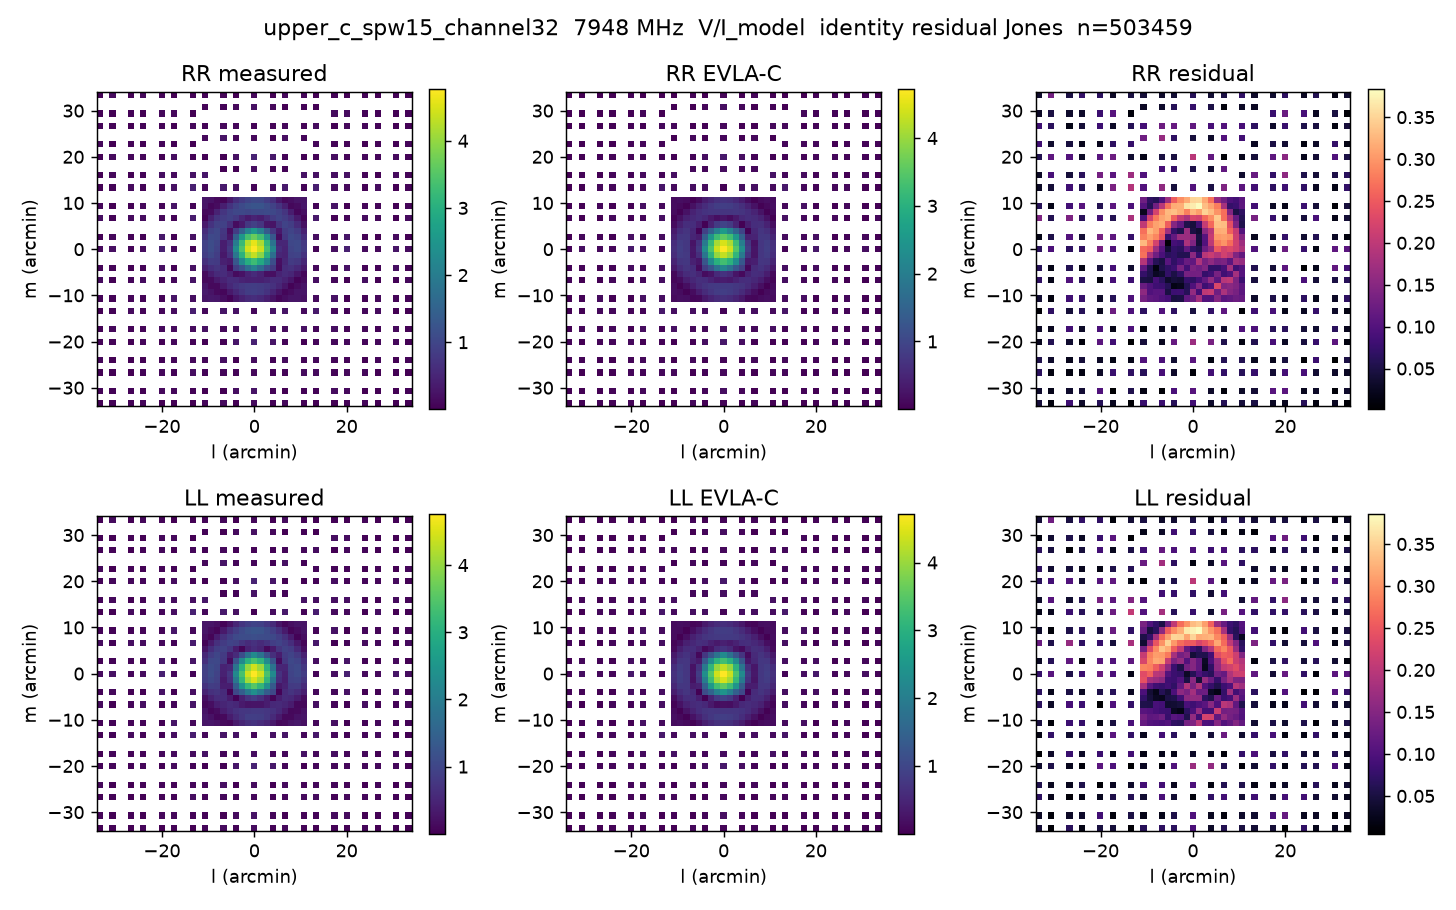

In [5]:
figures = [
    "frequency_radius_suitability.png",
    "pass_b_mainlobe.png",
    "nulls_vs_frequency.png",
    "spw02_channel32_spatial.png",
    "spw02_channel32_signed_cuts.png",
    "spw03_channel32_spatial.png",
    "spw03_channel32_signed_cuts.png",
    "spw04_channel32_spatial.png",
    "spw04_channel32_signed_cuts.png",
    "spw05_channel32_spatial.png",
    "spw05_channel32_signed_cuts.png",
    "spw06_channel32_spatial.png",
    "spw06_channel32_signed_cuts.png",
    "spw07_channel32_spatial.png",
    "spw07_channel32_signed_cuts.png",
    "spw15_channel32_spatial.png",
    "upper_c_spw00_channel32_spatial.png",
    "upper_c_spw01_channel32_spatial.png",
    "upper_c_spw15_channel32_spatial.png",
]
for name in figures:
    path = root / "figures" / name
    if not path.is_file():
        print("missing", name)
        continue
    print(name, path.stat().st_size)
    display(Image(filename=str(path)))
